In [27]:
# =========================
# IMPORTS
# =========================

import pandas as pd
import numpy as np

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


# =========================
# LOAD DATA
# =========================

train_raw = pd.read_csv(
    "/kaggle/input/competitions/dev-comm-jc-2026/train.csv"
)

test_raw = pd.read_csv(
    "/kaggle/input/competitions/dev-comm-jc-2026/test.csv"
)

test_ids = test_raw["PassengerId"].copy()



# =========================
# FEATURE ENGINEERING
# =========================

def feature_engineering(df, cabin_bins=None):

    df = df.copy()


    # -------------------------
    # Boolean conversion
    # -------------------------

    for col in ['VIP', 'CryoSleep']:

        if col in df.columns:
            df[col] = (
                df[col]
                .map({True:1, False:0})
                .astype('Int16')
            )


    if 'Transported' in df.columns:

        df['Transported'] = (
            df['Transported']
            .map({True:1, False:0})
            .astype('Int16')
        )



    # -------------------------
    # Group Features
    # -------------------------

    df['Group'] = (
        df['PassengerId']
        .str.split('_')
        .str[0]
        .astype('Int16')
    )


    df['GroupSize'] = (
        df.groupby('Group')['Group']
        .transform('count')
    )


    df['IsAlone'] = (
        df['GroupSize'] == 1
    ).astype('int8')



    # -------------------------
    # Cabin Features
    # -------------------------

    df['DeckNumber'] = (
        df['Cabin']
        .str.split('/')
        .str[0]
    )


    df['Side'] = (
        df['Cabin']
        .str.split('/')
        .str[2]
    )


    df['CabinNum'] = pd.to_numeric(
        df['Cabin']
        .str.split('/')
        .str[1],
        errors='coerce'
    )


    df['Deck_Side'] = (
        df['DeckNumber']
        .astype('string')
        +
        "_"
        +
        df['Side']
        .astype('string')
    )



    # -------------------------
    # Cabin Region
    # -------------------------

    if cabin_bins is None:

        df['CabinRegion'], cabin_bins = pd.qcut(
            df['CabinNum'],
            q=5,
            labels=False,
            retbins=True,
            duplicates='drop'
        )

    else:

        df['CabinRegion'] = pd.cut(
            df['CabinNum'],
            bins=cabin_bins,
            labels=False,
            include_lowest=True
        )



    # -------------------------
    # Group Side Filling
    # -------------------------

    group_side = df.groupby('Group')['Side'].apply(
        lambda x:
        x.dropna().iloc[0]
        if len(x.dropna()) > 0
        else np.nan
    )


    mask = (
        df['Side'].isna()
        &
        (df['GroupSize'] > 1)
    )


    df.loc[mask,'Side'] = (
        df.loc[mask,'Group']
        .map(group_side)
    )


    if 'Transported' in df.columns:

        df = df.dropna(
            subset=['Side']
        )

    else:

        df['Side'] = (
            df['Side']
            .fillna('Missing')
        )



    # -------------------------
    # Spending Features
    # -------------------------

    spend_cols = [
        'RoomService',
        'FoodCourt',
        'ShoppingMall',
        'Spa',
        'VRDeck'
    ]


    for col in spend_cols:
        df[col] = df[col].fillna(0)



    df['TotalSpend'] = (
        df[spend_cols]
        .sum(axis=1)
    )


    # NEW FEATURE ONLY
    df['LuxurySpend'] = (
        df['Spa']
        +
        df['VRDeck']
    )



    # -------------------------
    # Drop Columns
    # -------------------------

    df.drop(
        columns=[
            'PassengerId',
            'Cabin',
            'Name'
        ],
        inplace=True,
        errors='ignore'
    )



    # -------------------------
    # Categorical Features
    # -------------------------

    cat_features = [
        'HomePlanet',
        'Destination',
        'DeckNumber',
        'Side',
        'Deck_Side'
    ]


    for col in cat_features:

        if col in df.columns:

            df[col] = (
                df[col]
                .fillna('Missing')
                .astype(str)
            )


    return df, cabin_bins




# =========================
# APPLY FEATURES
# =========================

train_df, cabin_bins = feature_engineering(
    train_raw
)


test_df, _ = feature_engineering(
    test_raw,
    cabin_bins
)


print("Train:", train_df.shape)
print("Test:", test_df.shape)



# =========================
# SPLIT DATA
# =========================

X = train_df.drop(
    'Transported',
    axis=1
)

y = train_df['Transported']


cat_features = [
    'HomePlanet',
    'Destination',
    'DeckNumber',
    'Side',
    'Deck_Side'
]


X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



# =========================
# CATBOOST
# =========================

model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=42,
    l2_leaf_reg=5,
    random_strength=1,
    verbose=100
)


model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    use_best_model=True
)



# =========================
# VALIDATION
# =========================

val_pred = model.predict(X_val)


print(
    "Validation Accuracy:",
    accuracy_score(y_val,val_pred)
)


print(
    classification_report(
        y_val,
        val_pred
    )
)



# =========================
# FEATURE IMPORTANCE
# =========================

importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": model.get_feature_importance()
    }
).sort_values(
    by="Importance",
    ascending=False
)


print(importance)



# =========================
# TEST PREDICTION
# =========================

test_pred = model.predict(test_df)



# =========================
# SUBMISSION
# =========================

submission = pd.DataFrame(
    {
        "PassengerId": test_ids,
        "Transported": test_pred.astype(bool)
    }
)


submission.to_csv(
    "submission.csv",
    index=False
)


print(submission.head())
print(submission.shape)

Train: (8594, 21)
Test: (4277, 20)
0:	learn: 0.7694545	test: 0.7684700	best: 0.7684700 (0)	total: 12.1ms	remaining: 18.2s
100:	learn: 0.8088727	test: 0.8155905	best: 0.8161722 (82)	total: 1.08s	remaining: 15s
200:	learn: 0.8235636	test: 0.8202443	best: 0.8214078 (186)	total: 2.18s	remaining: 14.1s
300:	learn: 0.8352000	test: 0.8260617	best: 0.8283886 (249)	total: 3.25s	remaining: 13s
400:	learn: 0.8437818	test: 0.8225713	best: 0.8283886 (249)	total: 4.32s	remaining: 11.8s
500:	learn: 0.8549818	test: 0.8219895	best: 0.8283886 (249)	total: 5.4s	remaining: 10.8s
600:	learn: 0.8624000	test: 0.8214078	best: 0.8283886 (249)	total: 6.43s	remaining: 9.61s
700:	learn: 0.8670545	test: 0.8214078	best: 0.8283886 (249)	total: 7.5s	remaining: 8.55s
800:	learn: 0.8730182	test: 0.8196626	best: 0.8283886 (249)	total: 8.59s	remaining: 7.49s
900:	learn: 0.8782545	test: 0.8190809	best: 0.8283886 (249)	total: 9.64s	remaining: 6.41s
1000:	learn: 0.8862545	test: 0.8161722	best: 0.8283886 (249)	total: 10.7s	r

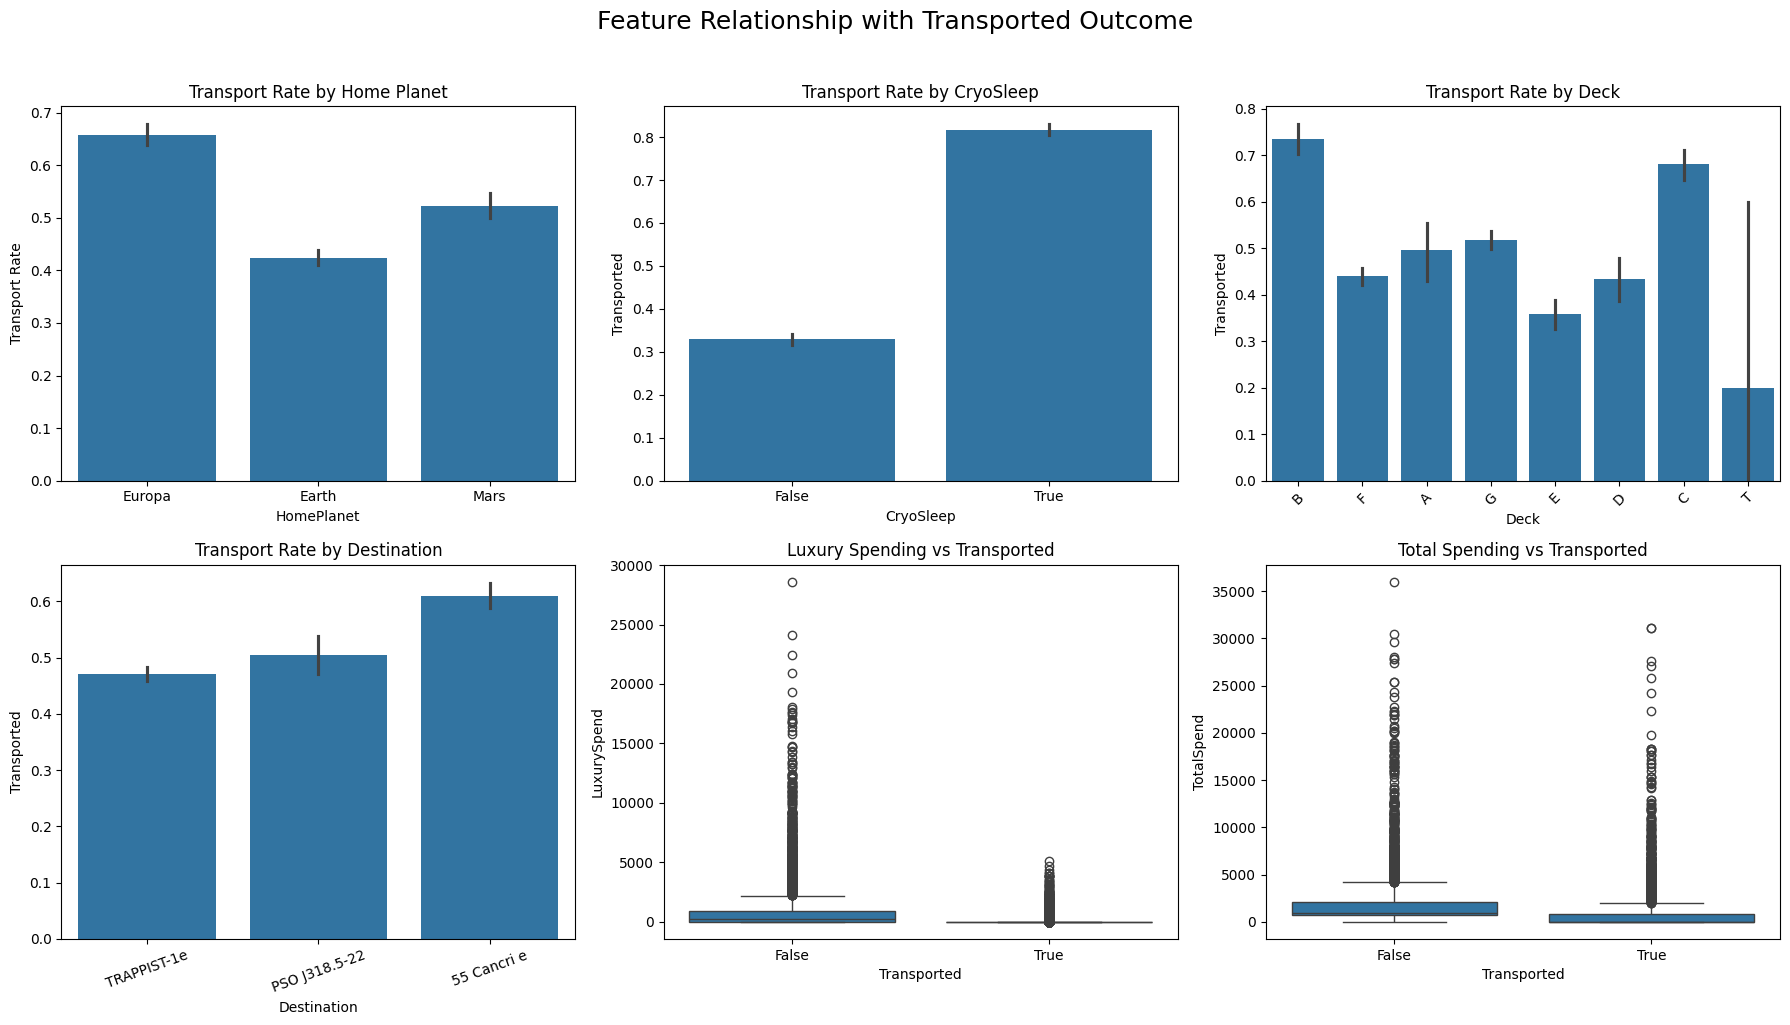

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# =========================
# CREATE REQUIRED FEATURES
# =========================

plot_df = train_raw.copy()


# Extract Deck
plot_df['Deck'] = (
    plot_df['Cabin']
    .str.split('/')
    .str[0]
)


# Spending
spend_cols = [
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck'
]

for col in spend_cols:
    plot_df[col] = plot_df[col].fillna(0)


plot_df['TotalSpend'] = (
    plot_df[spend_cols]
    .sum(axis=1)
)


plot_df['LuxurySpend'] = (
    plot_df['Spa']
    +
    plot_df['VRDeck']
)



# =========================
# SUBPLOTS
# =========================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,10)
)


# -------------------------
# HomePlanet vs Transported
# -------------------------

sns.barplot(
    data=plot_df,
    x='HomePlanet',
    y='Transported',
    ax=axes[0,0]
)

axes[0,0].set_title(
    "Transport Rate by Home Planet"
)

axes[0,0].set_ylabel(
    "Transport Rate"
)



# -------------------------
# CryoSleep vs Transported
# -------------------------

sns.barplot(
    data=plot_df,
    x='CryoSleep',
    y='Transported',
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Transport Rate by CryoSleep"
)



# -------------------------
# Deck vs Transported
# -------------------------

sns.barplot(
    data=plot_df,
    x='Deck',
    y='Transported',
    ax=axes[0,2]
)

axes[0,2].set_title(
    "Transport Rate by Deck"
)

axes[0,2].tick_params(
    axis='x',
    rotation=45
)



# -------------------------
# Destination vs Transported
# -------------------------

sns.barplot(
    data=plot_df,
    x='Destination',
    y='Transported',
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Transport Rate by Destination"
)

axes[1,0].tick_params(
    axis='x',
    rotation=20
)



# -------------------------
# LuxurySpend vs Transported
# -------------------------

sns.boxplot(
    data=plot_df,
    x='Transported',
    y='LuxurySpend',
    ax=axes[1,1]
)

axes[1,1].set_title(
    "Luxury Spending vs Transported"
)



# -------------------------
# TotalSpend vs Transported
# -------------------------

sns.boxplot(
    data=plot_df,
    x='Transported',
    y='TotalSpend',
    ax=axes[1,2]
)

axes[1,2].set_title(
    "Total Spending vs Transported"
)



# Layout
plt.suptitle(
    "Feature Relationship with Transported Outcome",
    fontsize=18,
    y=1.02
)


plt.tight_layout()

plt.show()

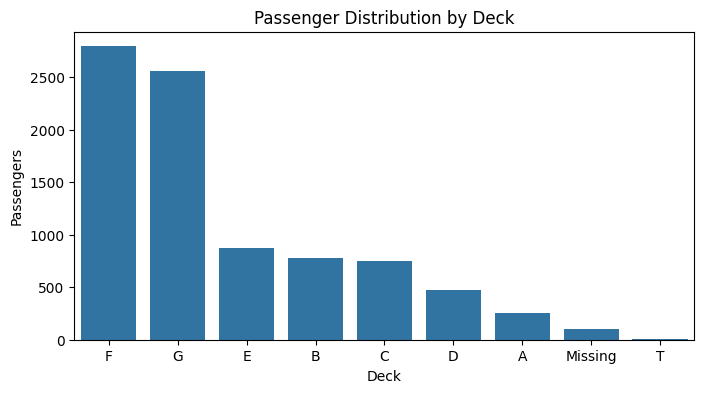

In [31]:
plt.figure(figsize=(8,4))

deck_counts = (
    train_df['DeckNumber']
    .value_counts()
)

sns.barplot(
    x=deck_counts.index,
    y=deck_counts.values
)

plt.title("Passenger Distribution by Deck")
plt.xlabel("Deck")
plt.ylabel("Passengers")

plt.show()

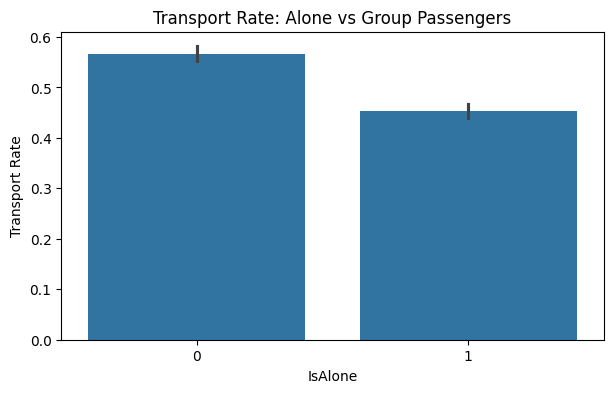

In [32]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=train_df,
    x='IsAlone',
    y='Transported'
)

plt.title("Transport Rate: Alone vs Group Passengers")
plt.ylabel("Transport Rate")

plt.show()

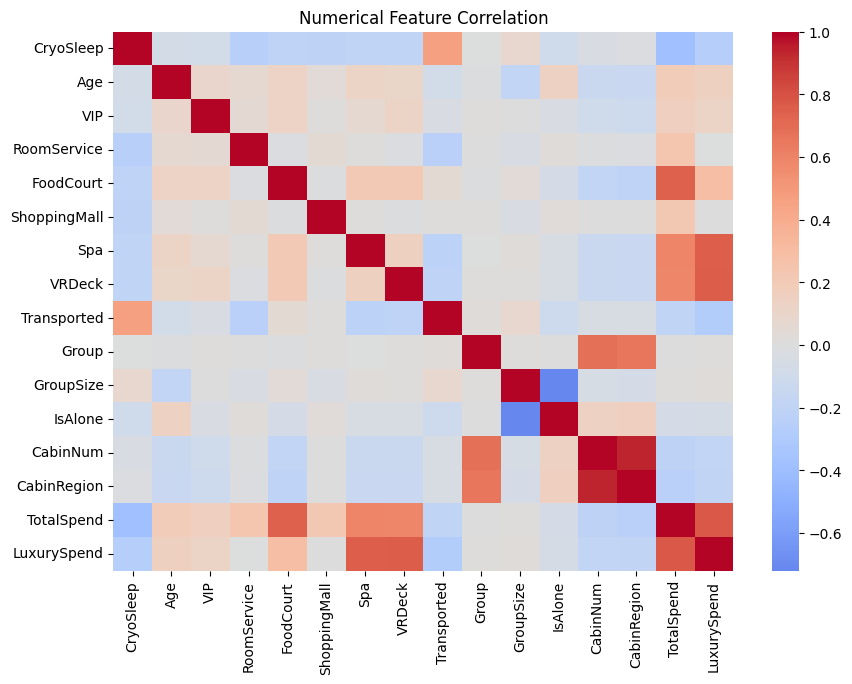

In [34]:
plt.figure(figsize=(10,7))

numeric = train_df.select_dtypes(
    include=np.number
)


sns.heatmap(
    numeric.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Numerical Feature Correlation")

plt.show()

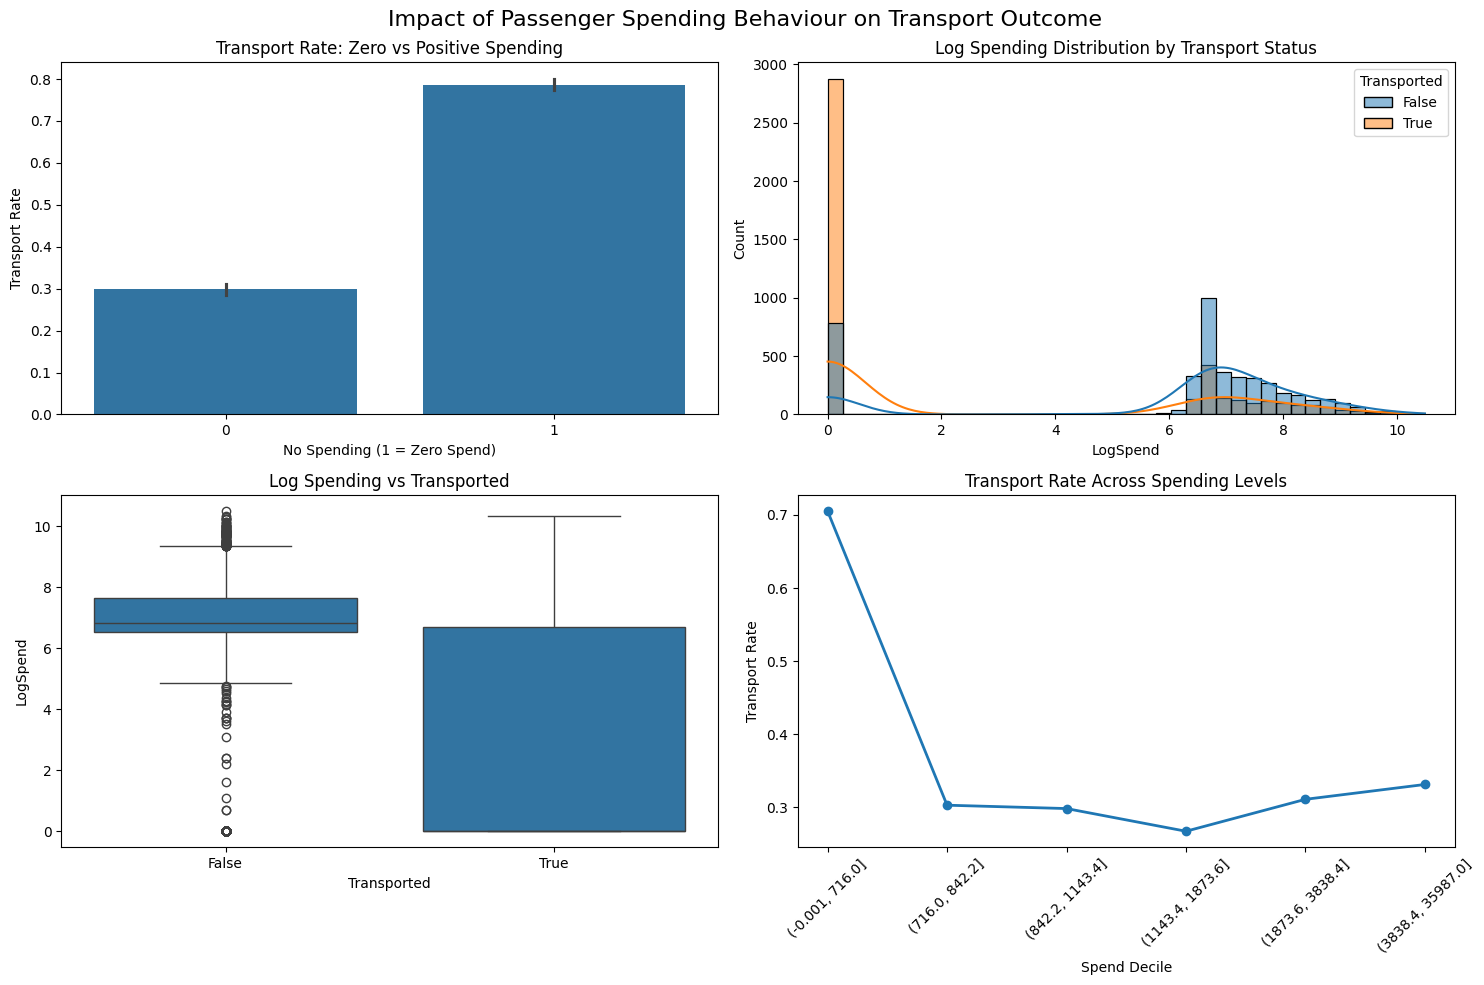

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =========================
# Spending Feature Creation
# =========================

df = train_raw.copy()

spend_cols = [
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck'
]

for col in spend_cols:
    df[col] = df[col].fillna(0)


df['TotalSpend'] = (
    df[spend_cols]
    .sum(axis=1)
)


df['LogSpend'] = np.log1p(
    df['TotalSpend']
)


df['NoSpend'] = (
    df['TotalSpend'] == 0
).astype(int)



# =========================
# SUBPLOTS
# =========================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15,10)
)


# -------------------------
# 1. No Spend vs Transported
# -------------------------

sns.barplot(
    data=df,
    x='NoSpend',
    y='Transported',
    ax=axes[0,0]
)

axes[0,0].set_title(
    "Transport Rate: Zero vs Positive Spending"
)

axes[0,0].set_xlabel(
    "No Spending (1 = Zero Spend)"
)

axes[0,0].set_ylabel(
    "Transport Rate"
)



# -------------------------
# 2. Log Spending Distribution
# -------------------------

sns.histplot(
    data=df,
    x='LogSpend',
    hue='Transported',
    kde=True,
    bins=40,
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Log Spending Distribution by Transport Status"
)



# -------------------------
# 3. LogSpend Boxplot
# -------------------------

sns.boxplot(
    data=df,
    x='Transported',
    y='LogSpend',
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Log Spending vs Transported"
)



# -------------------------
# 4. Spend Decile Trend
# -------------------------

df['SpendDecile'] = pd.qcut(
    df['TotalSpend'],
    q=10,
    duplicates='drop'
)


(
    df.groupby(
        'SpendDecile',
        observed=False
    )['Transported']
    .mean()
    .plot(
        marker='o',
        linewidth=2,
        ax=axes[1,1]
    )
)


axes[1,1].set_title(
    "Transport Rate Across Spending Levels"
)

axes[1,1].set_xlabel(
    "Spend Decile"
)

axes[1,1].set_ylabel(
    "Transport Rate"
)

axes[1,1].tick_params(
    axis='x',
    rotation=45
)



plt.suptitle(
    "Impact of Passenger Spending Behaviour on Transport Outcome",
    fontsize=16
)


plt.tight_layout()

plt.show()

Subgroup Size: 518
Transport Rate: 0.6158301158301158


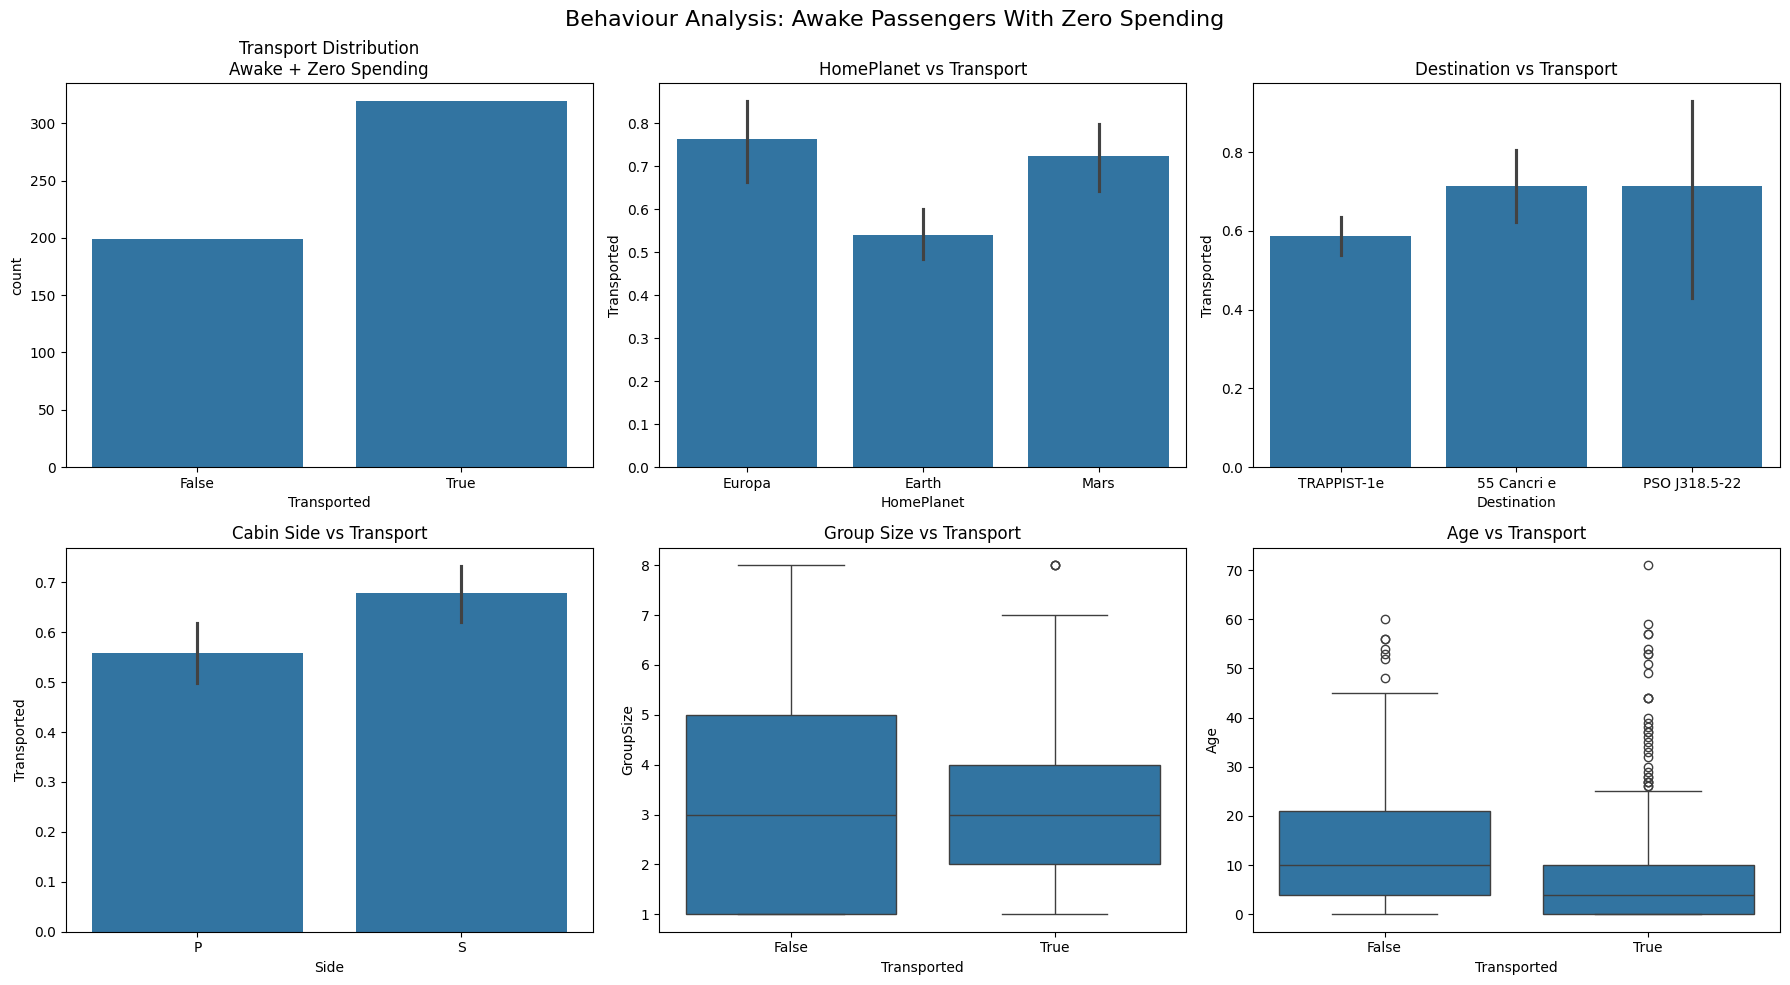

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# =========================
# CREATE REQUIRED FEATURES
# =========================

# Side from Cabin
if 'Side' not in df.columns:
    df['Side'] = (
        df['Cabin']
        .str.split('/')
        .str[2]
    )


# Group features
if 'GroupSize' not in df.columns:

    df['Group'] = (
        df['PassengerId']
        .str.split('_')
        .str[0]
    )

    df['GroupSize'] = (
        df.groupby('Group')['Group']
        .transform('count')
    )


# Spending features
spend_cols = [
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck'
]

for col in spend_cols:
    df[col] = df[col].fillna(0)


df['TotalSpend'] = (
    df[spend_cols]
    .sum(axis=1)
)


df['NoSpend'] = (
    df['TotalSpend'] == 0
).astype(int)



# =========================
# CREATE SUBGROUP
# =========================

subset = df[
    (df['CryoSleep'] == False) &
    (df['NoSpend'] == 1)
].copy()



print("Subgroup Size:", len(subset))

print(
    "Transport Rate:",
    subset['Transported'].mean()
)



# =========================
# PLOTS
# =========================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,10)
)



# 1 Transport distribution

sns.countplot(
    data=subset,
    x='Transported',
    ax=axes[0,0]
)

axes[0,0].set_title(
    "Transport Distribution\nAwake + Zero Spending"
)



# 2 HomePlanet

sns.barplot(
    data=subset,
    x='HomePlanet',
    y='Transported',
    ax=axes[0,1]
)

axes[0,1].set_title(
    "HomePlanet vs Transport"
)



# 3 Destination

sns.barplot(
    data=subset,
    x='Destination',
    y='Transported',
    ax=axes[0,2]
)

axes[0,2].set_title(
    "Destination vs Transport"
)



# 4 Side

sns.barplot(
    data=subset,
    x='Side',
    y='Transported',
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Cabin Side vs Transport"
)



# 5 Group Size

sns.boxplot(
    data=subset,
    x='Transported',
    y='GroupSize',
    ax=axes[1,1]
)

axes[1,1].set_title(
    "Group Size vs Transport"
)



# 6 Age

sns.boxplot(
    data=subset,
    x='Transported',
    y='Age',
    ax=axes[1,2]
)

axes[1,2].set_title(
    "Age vs Transport"
)



plt.suptitle(
    "Behaviour Analysis: Awake Passengers With Zero Spending",
    fontsize=16
)


plt.tight_layout()

plt.show()

In [ ]:
# EDA Summary: CryoSleep, NoSpend, Age and Transported
#
# Initial analysis showed that passengers with NoSpend=1 had a transport rate
# of 78.6%, compared to only 29.9% for passengers with positive expenditure.
# This suggested that the distinction between spending and non-spending passengers
# is far more important than the actual amount spent.
#
# Further investigation revealed a very strong relationship between CryoSleep
# and spending behavior:
#
#   CryoSleep = 1  --> 100% NoSpend
#   CryoSleep = 0  --> 90.5% spent money
#
# indicating that CryoSleep and NoSpend are highly related, but not identical.
#
# To determine whether NoSpend was simply a proxy for CryoSleep, the subgroup
# CryoSleep=0 and NoSpend=1 was analyzed separately. Surprisingly, these passengers
# still exhibited a transport rate of 61.6%, much higher than the baseline
# transport rate for spending passengers (~30%).
#
# Examination of this subgroup showed:
#
#   Median Age = 7 years
#   Mean Age = 10.5 years
#   75% of passengers were aged 12 or younger
#   Median GroupSize = 3
#
# suggesting that many of these passengers are children travelling with families.
# Since children are less likely to use paid onboard services, they frequently
# appear as NoSpend passengers despite not being in CryoSleep.
#
# Age analysis confirmed a strong child effect:
#
#   Adults (Age >= 13): 48.4% transported
#   Children (Age < 13): 70.0% transported
#
# Cross-analysis of CryoSleep and Age revealed two distinct behavioral regimes:
#
#   Adult + No CryoSleep  --> 30.0% transported
#   Adult + CryoSleep     --> 83.1% transported
#
#   Child + No CryoSleep  --> 68.2% transported
#   Child + CryoSleep     --> 72.4% transported
#
# This indicates that CryoSleep is an extremely strong predictor for adults,
# increasing transport probability from 30% to 83%. For children, transport
# probability is already high regardless of CryoSleep status.
#
# Conclusion:
#
# 1. CryoSleep is one of the strongest predictors of Transported.
# 2. NoSpend is not merely a duplicate of CryoSleep and captures additional
#    behavioral information.
# 3. Children naturally have a much higher transport probability than adults.
# 4. The high transport rate among CryoSleep=0 & NoSpend=1 passengers is largely
#    explained by the presence of young passengers travelling in groups.
# 5. The dataset appears to contain two major behavioral patterns:
#       - Adults: strongly influenced by CryoSleep and spending behavior.
#       - Children: inherently more likely to be transported.

NoSpend vs Transported
CryoSleep vs NoSpend relationship
CryoSleep + NoSpend subgroup
Age distribution
Age group (Adult vs Child) vs Transported
CryoSleep + Age interaction
GroupSize analysis

1. NoSpend vs Transported
Transported     False     True 
NoSpend                        
0            0.701389  0.298611
1            0.213523  0.786477


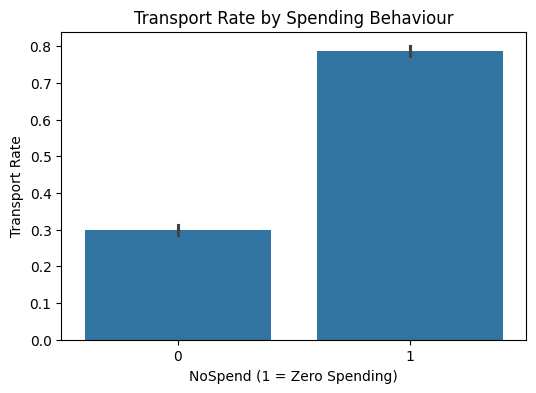

2. CryoSleep vs NoSpend
NoSpend           0         1
CryoSleep                    
False      0.904762  0.095238
True       0.000000  1.000000


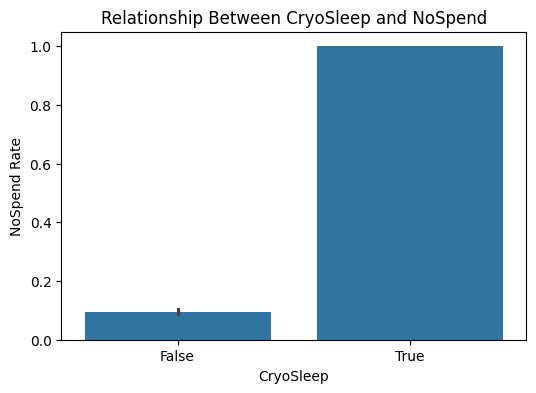

3. Awake + Zero Spending Subgroup
Subgroup Size: 518

Transport Distribution
Transported
True     0.61583
False    0.38417
Name: proportion, dtype: float64


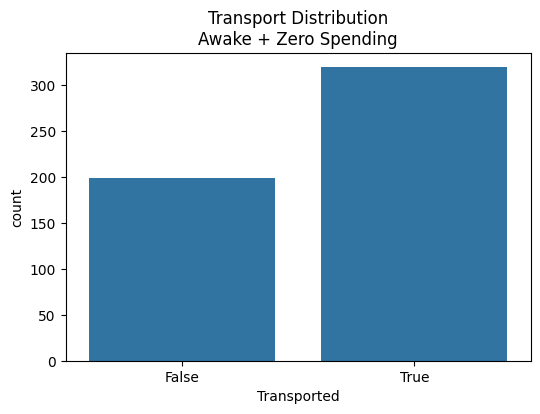

4. Age Statistics
count    511.000000
mean      10.463796
std       12.880832
min        0.000000
25%        2.000000
50%        7.000000
75%       12.000000
max       71.000000
Name: Age, dtype: float64


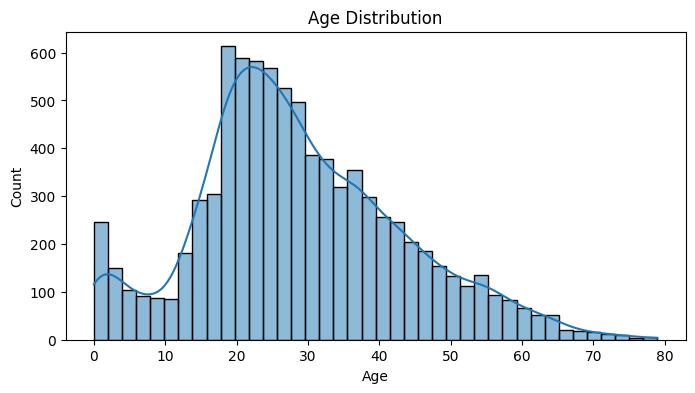

5. Adult vs Child Transport
Transported     False     True 
AgeGroup                       
Adult        0.516419  0.483581
Child        0.300248  0.699752


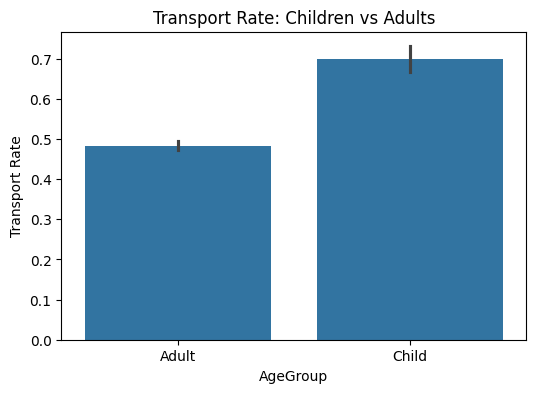

6. AgeGroup + CryoSleep vs Transported
Transported            False     True 
AgeGroup CryoSleep                    
Adult    False      0.699583  0.300417
         True       0.169173  0.830827
Child    False      0.317734  0.682266
         True       0.275862  0.724138


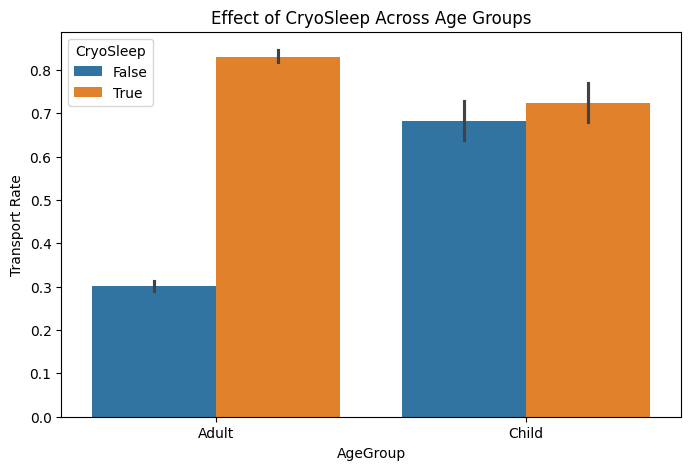

7. GroupSize vs Transported
Transported     False     True 
GroupSize                      
1            0.547555  0.452445
2            0.461950  0.538050
3            0.406863  0.593137
4            0.359223  0.640777
5            0.407547  0.592453
6            0.385057  0.614943
7            0.458874  0.541126
8            0.605769  0.394231


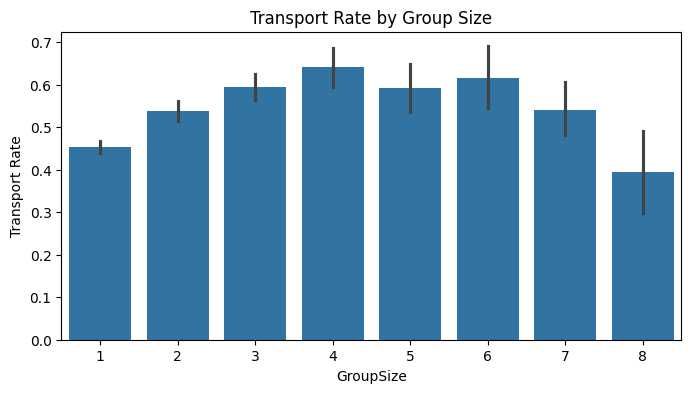

8. Awake + Zero Spend Detailed Statistics

Age Statistics
count    511.000000
mean      10.463796
std       12.880832
min        0.000000
25%        2.000000
50%        7.000000
75%       12.000000
max       71.000000
Name: Age, dtype: float64

Group Size Statistics
count    518.000000
mean       3.413127
std        1.881186
min        1.000000
25%        2.000000
50%        3.000000
75%        5.000000
max        8.000000
Name: GroupSize, dtype: float64


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# ==========================================================
# 1. NoSpend vs Transported
# ==========================================================

print("="*60)
print("1. NoSpend vs Transported")
print("="*60)

print(
    pd.crosstab(
        df['NoSpend'],
        df['Transported'],
        normalize='index'
    )
)


plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x='NoSpend',
    y='Transported'
)

plt.title(
    "Transport Rate by Spending Behaviour"
)

plt.xlabel(
    "NoSpend (1 = Zero Spending)"
)

plt.ylabel(
    "Transport Rate"
)

plt.show()





# ==========================================================
# 2. CryoSleep vs NoSpend Relationship
# ==========================================================

print("="*60)
print("2. CryoSleep vs NoSpend")
print("="*60)

print(
    pd.crosstab(
        df['CryoSleep'],
        df['NoSpend'],
        normalize='index'
    )
)


plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x='CryoSleep',
    y='NoSpend'
)

plt.title(
    "Relationship Between CryoSleep and NoSpend"
)

plt.ylabel(
    "NoSpend Rate"
)

plt.show()





# ==========================================================
# 3. CryoSleep=0 & NoSpend=1 Subgroup
# ==========================================================

print("="*60)
print("3. Awake + Zero Spending Subgroup")
print("="*60)


subset = df[
    (df['CryoSleep']==False) &
    (df['NoSpend']==1)
].copy()


print(
    "Subgroup Size:",
    len(subset)
)


print("\nTransport Distribution")

print(
    subset['Transported']
    .value_counts(normalize=True)
)


plt.figure(figsize=(6,4))

sns.countplot(
    data=subset,
    x='Transported'
)

plt.title(
    "Transport Distribution\nAwake + Zero Spending"
)

plt.show()





# ==========================================================
# 4. Age Distribution
# ==========================================================

print("="*60)
print("4. Age Statistics")
print("="*60)


print(
    subset['Age']
    .describe()
)


plt.figure(figsize=(8,4))

sns.histplot(
    df['Age'],
    bins=40,
    kde=True
)

plt.title(
    "Age Distribution"
)

plt.show()





# ==========================================================
# 5. Adult vs Child Transport Rate
# ==========================================================

print("="*60)
print("5. Adult vs Child Transport")
print("="*60)


df['AgeGroup'] = np.where(
    df['Age'] < 13,
    'Child',
    'Adult'
)


print(
    pd.crosstab(
        df['AgeGroup'],
        df['Transported'],
        normalize='index'
    )
)


plt.figure(figsize=(6,4))


sns.barplot(
    data=df,
    x='AgeGroup',
    y='Transported'
)


plt.title(
    "Transport Rate: Children vs Adults"
)


plt.ylabel(
    "Transport Rate"
)


plt.show()





# ==========================================================
# 6. CryoSleep + Age Interaction
# ==========================================================

print("="*60)
print("6. AgeGroup + CryoSleep vs Transported")
print("="*60)


print(
    pd.crosstab(
        [
            df['AgeGroup'],
            df['CryoSleep']
        ],
        df['Transported'],
        normalize='index'
    )
)



plt.figure(figsize=(8,5))


sns.barplot(
    data=df,
    x='AgeGroup',
    y='Transported',
    hue='CryoSleep'
)


plt.title(
    "Effect of CryoSleep Across Age Groups"
)


plt.ylabel(
    "Transport Rate"
)


plt.show()





# ==========================================================
# 7. Group Size Analysis
# ==========================================================

print("="*60)
print("7. GroupSize vs Transported")
print("="*60)


print(
    pd.crosstab(
        df['GroupSize'],
        df['Transported'],
        normalize='index'
    )
)



plt.figure(figsize=(8,4))


sns.barplot(
    data=df,
    x='GroupSize',
    y='Transported'
)


plt.title(
    "Transport Rate by Group Size"
)


plt.ylabel(
    "Transport Rate"
)


plt.show()





# ==========================================================
# 8. Subgroup Detailed Statistics
# ==========================================================

print("="*60)
print("8. Awake + Zero Spend Detailed Statistics")
print("="*60)


print("\nAge Statistics")

print(
    subset['Age']
    .describe()
)


print("\nGroup Size Statistics")

print(
    subset['GroupSize']
    .describe()
)

Age Group vs Transported
Transported      False     True 
AgeGroupBins                    
0-5           0.271028  0.728972
6-10          0.406393  0.593607
11-13         0.441048  0.558952
14-18         0.458606  0.541394
19-30         0.531810  0.468190
31-50         0.520568  0.479432
50+           0.515604  0.484396


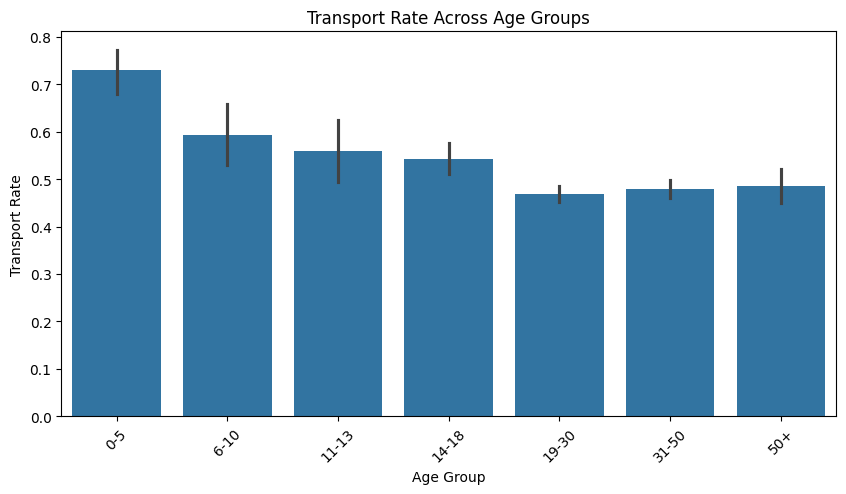

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns


# =========================
# Age vs Transported Analysis
# =========================


# Create age bins
df['AgeGroupBins'] = pd.cut(
    df['Age'],
    bins=[0,5,10,13,18,30,50,100],
    labels=[
        "0-5",
        "6-10",
        "11-13",
        "14-18",
        "19-30",
        "31-50",
        "50+"
    ]
)


# Crosstab
print("="*60)
print("Age Group vs Transported")
print("="*60)


print(
    pd.crosstab(
        df['AgeGroupBins'],
        df['Transported'],
        normalize='index'
    )
)



# Plot

plt.figure(figsize=(10,5))


sns.barplot(
    data=df,
    x='AgeGroupBins',
    y='Transported'
)


plt.title(
    "Transport Rate Across Age Groups"
)

plt.xlabel(
    "Age Group"
)

plt.ylabel(
    "Transport Rate"
)

plt.xticks(
    rotation=45
)

plt.show()

IsChild vs Transported
Transported     False     True 
IsChild                        
0            0.516419  0.483581
1            0.300248  0.699752


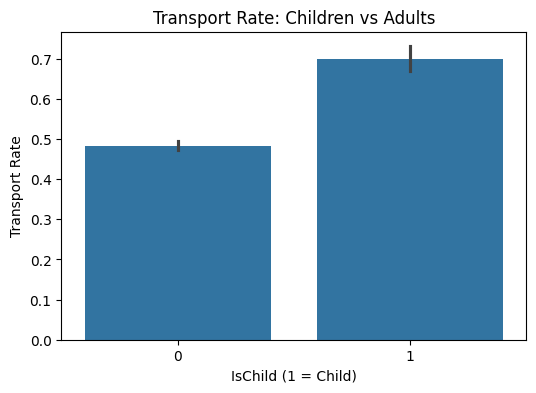

In [42]:
# =========================
# Create IsChild Feature
# =========================

df['IsChild'] = (
    df['Age'] < 13
).astype(int)

print("="*60)
print("IsChild vs Transported")
print("="*60)

print(
    pd.crosstab(
        df['IsChild'],
        df['Transported'],
        normalize='index'
    )
)


plt.figure(figsize=(6,4))


sns.barplot(
    data=df,
    x='IsChild',
    y='Transported'
)


plt.title(
    "Transport Rate: Children vs Adults"
)

plt.xlabel(
    "IsChild (1 = Child)"
)

plt.ylabel(
    "Transport Rate"
)

plt.show()